In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from sklearn.metrics import r2_score

import os
import sys

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')

from funcs import *
from clean_and_combine import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Scaling waves

I have gathered the results of the waves tank experiments conducted by Maxime Leclerc during the spring semester 2025. My findings are in the folders /20_cm, /30_cm, /40_cm, where I assessed the waves ran for the three different water depths and for the 6 different frequencies per water depth. For each water depth and frequency configuration, Maxime ran the waves with and without plates mounted at the bottom, for 5 different positions of the probe array. Each configuration (water depth, plates/no plates, frequency, probe position) was run 3 times. So, in order to get an overview and to assess which runs gave meaningful damping, I picked out four probes per water depth - frequency - plate configuration (1 reference probe before the plates, and 3 probes evenly spaced over the plates). From this, I found that there were no damping which were within the accuracy of the probes for the deeper waters levels. 

## Methods used for the results:
For a given experiment of X cm water depth for a given frequency and amplitude I, 

1) Opened all three runs for experiments with both plates and empty tank.
2) Combined the three respective runs for experiment with plates and empty tank.
3) Subtracted the mean of the first 200 rows in the data to take out probe noise.
4) Applied a low-pass filter to smooth out outliers.
5) Took the mean of the three runs. So I was left with one dataset with plates and one without.
6) Selected 4 probes from the virtual array of 20 probes to look at. The placements of the probes chosen was then $11.075, 12.595, 13.81, 15.33$. The plates were placed between $12.4$ m and $15.45$ m.
7) Plotted the signal from the first probe, as this is not disturbed by the plates. From this plot, I visually decided at which point in time the wave train sabilized.
8) Used the timestamp of stable waves and cut off the first part of the signal for all probes. 
9) Tried to find a method for cutting off parts of the signal which contains reflected waves. With no luck. Perhaps because there were no waves that were stabilized + not reflected (due to the waves being long and the probes being placed in the middle of the tank).
10) Subtracted the mean of each probe signal from the data to again avoid gauge noise. Then found the standard deviation of each probe, and from there found the amplitude.
11) Saw how the amplitude changed from probe to probe.
12) Estimated wave number and frequency by Fourier transform. 
13) Used this to calculate the dimensionless variables, $kH$ and $ak$.

* Amplitude difference from before plates to the end of the plates: $ A_{diff} = A_{x=11.075 m} - A_{x=15.33 m}$
* Percentage damping due to plates = $\frac{A_{diff}^{plates + walls} - A_{diff}^{walls}}{A_{diff}^{plates + walls}}$

## Method for scaling

Take one original wave at depth $H_1$, with wave steepness $k_1*a_1$ and relative depth $k_1*H_1$. We want to scale this wave by keeping these two constant.
So for a new wave with depth $H_2$, we should have:

$k_1*a_1 = k_2*a_2$ and $k_1*H_1 = k_2*H_2$.

So,
$$k_2 = \frac{k_1 H_1}{H_2}$$
$$a_2 = \frac{k_1 a_1}{k_2} = \frac{a_1 H_2}{H_1}$$

And thus for the dispersion relation,
$$\omega_1^2 = gk_1 tanh(k_1 H_1)$$
$$\omega_2^2 = gk_2 tanh(k_2 H_2)$$

but with $k_1*H_1 = k_2*H_2$ we have that $tanh(k_1 H_1) = tanh(k_2 H_2)$.

So,
$$\omega_2^2 = g k_2 \frac{\omega_1^2}{g k_1} = \frac{k_2}{k_1}\omega_1^2$$
$$\omega_2 = \omega_1 \sqrt{\frac{k_2}{k_1}} = \omega_1 \sqrt{\frac{H_1}{H_2}}$$

### Reminder of wave properties
* The wavelength is $\lambda = \frac{2 \pi}{k}$
* Wave period is $T = \frac{2 \pi}{\omega} = \frac{1}{f}$
* Frequency is $f = \frac{1}{T}$
* Angular frequency $\omega = 2\pi f$
* Phase speed, $c = \frac{\omega}{k} = f \lambda$

## Scaled waves

Based of the results of the waves ran on 20 cm by Maxime, I will scale the waves to 30 cm water depth.
It was only in the 20 cm water depth waves that any damping larger than the accuracy of the probes was observed.

In [7]:
original_frequencies = [1.53, 1.37, 1.22, 1.07, 0.92, 0.76]
original_amplitudes  = [0.009, 0.0083, 0.0074, 0.0064, 0.0053, 0.0043]
original_wavelengths = [0.63, 0.77, 0.91, 1.1, 1.33, 1.69]

original_wave_numbers = [2 * np.pi / l for l in original_wavelengths]

H_1 = 0.2  # original depth
H_2 = 0.3  
H_3 = 0.4  

results = []

for f, a, k, lamb in zip(original_frequencies, original_amplitudes, original_wave_numbers, original_wavelengths):
    w = 2 * np.pi * f

    # --- Scaling to 30 cm ---
    w_new_2 = w * np.sqrt(H_1 / H_2)
    f_new_2 = w_new_2 / (2 * np.pi)
    a_new_2 = a * H_2 / H_1
    k_new_2 = k * H_1 / H_2
    lamb_new_2 = 2 * np.pi / k_new_2
    kH_new_2 = k_new_2 * H_2
    ak_new_2 = a_new_2 * k_new_2

    results.append({
        'f 20 cm': f,
        'a 20 cm': a,
        'k 20 cm': k,
        'λ 20 cm': lamb,
        'f 30 cm': f_new_2,
        'a 30 cm': a_new_2,
        'k 30 cm': k_new_2,
        'λ 30 cm': lamb_new_2,
        'kH': k * H_1,
        'ak': a * k,
    })

results_df_from_20cm = pd.DataFrame(results)

"""     # --- Scaling to 40 cm ---
    w_new_3 = w * np.sqrt(H_1 / H_3)
    f_new_3 = w_new_3 / (2 * np.pi)
    a_new_3 = a * H_3 / H_1
    k_new_3 = k * H_1 / H_3
    lamb_new_3 = 2 * np.pi / k_new_3
    kH_new_3 = k_new_3 * H_3
    ak_new_3 = a_new_3 * k_new_3 """

'     # --- Scaling to 40 cm ---\n    w_new_3 = w * np.sqrt(H_1 / H_3)\n    f_new_3 = w_new_3 / (2 * np.pi)\n    a_new_3 = a * H_3 / H_1\n    k_new_3 = k * H_1 / H_3\n    lamb_new_3 = 2 * np.pi / k_new_3\n    kH_new_3 = k_new_3 * H_3\n    ak_new_3 = a_new_3 * k_new_3 '

In [8]:
# Scaled results from 20 cm depth to 30 cm and 40 cm depths
results_df_from_20cm

,f 20 cm,a 20 cm,k 20 cm,λ 20 cm,f 30 cm,a 30 cm,k 30 cm,λ 30 cm,kH,ak
0,1.53,0.0090,9.973310,0.63,1.249240,0.01350,6.648873,0.945,1.994662,0.089760
1,1.37,0.0083,8.159981,0.77,1.118600,0.01245,5.439987,1.155,1.631996,0.067728
2,1.22,0.0074,6.904599,0.91,0.996126,0.01110,4.603066,1.365,1.380920,0.051094
3,1.07,0.0064,5.711987,1.10,0.873651,0.00960,3.807991,1.650,1.142397,0.036557
4,0.92,0.0053,4.724199,1.33,0.751177,0.00795,3.149466,1.995,0.944840,0.025038
5,0.76,0.0043,3.717861,1.69,0.620537,0.00645,2.478574,2.535,0.743572,0.015987


# Designing my wave experiments based of Maximes results

Maxime detected damping larger than the accuracy of the probes at 20 cm water depth. Damping was seen for frequencies: 1.22, 1.37, 1.53.

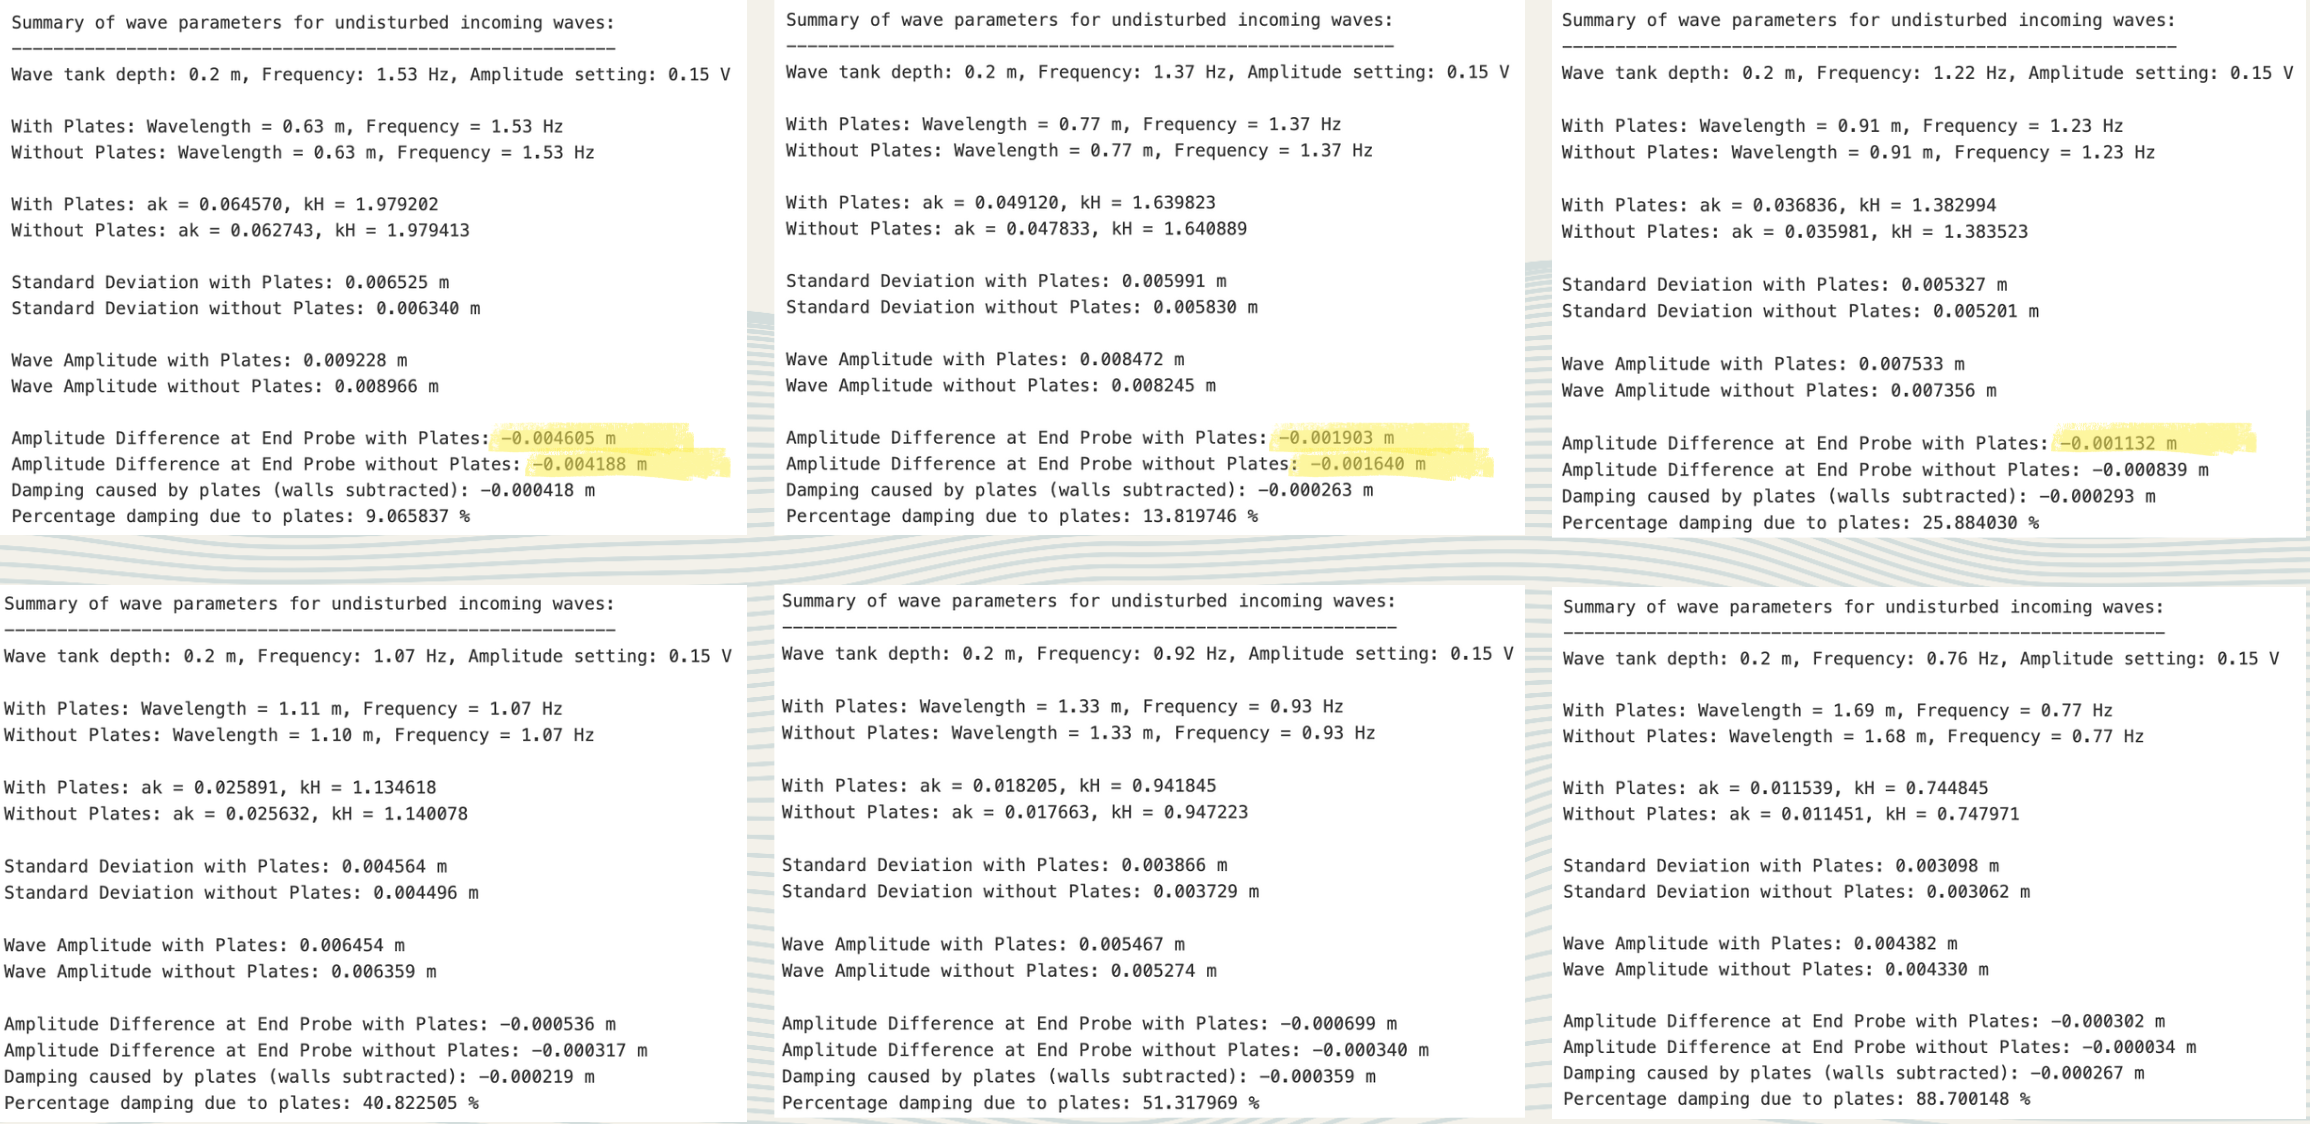

In [3]:
image_path = '/Users/kjesta/Desktop/Master prosjekt/Figurer/dempning_20cm_maxime.png'
display(Image(filename=image_path))

However, I found that three of the waves ran on 20 cm gave damping. Specifically, waves with 1.22 Hz, 1.37 Hz and 1.53 Hz with amplitude of 0.15 V gave damping larger than probe accuracy. I will therefore conduct similar experiments, but focus on a higher range of frequencies. To decrease the damping to error ratio, I will also increase the amplitude setting somewhat. This will be a tradeoff on linearity and relative depth parameter. 

Inital set of experiments at 20 cm water depth, without plates, are:
* f = 1.1 Hz, A = 0.1 V, 0.2 V, 0.3 V
* f = 1.2 Hz, A = 0.1 V, 0.2 V, 0.3 V
* f = 1.3 Hz, A = 0.1 V, 0.2 V, 0.3 V
* f = 1.4 Hz, A = 0.1 V, 0.2 V, 0.3 V
* f = 1.5 Hz, A = 0.1 V, 0.2 V, 0.3 V
* f = 1.6 Hz, A = 0.1 V, 0.2 V, 0.3 V
* f = 1.7 Hz, A = 0.1 V, 0.2 V, 0.3 V
* f = 1.8 Hz, A = 0.1 V, 0.2 V, 0.25 V

When completed, I will analyze these data and see if a) there is a linear relationship between the real amplitude and the voltage setting in WaveLab, and b) calculate the observed frequency, real amplitude, wave number and so on, to scale the waves to 30 cm water depth. That means that the viscous boundary layers relatively speaking becomes smaller, and we expect less damping.